In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

In [2]:
pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
import numpy as np
import os
import shutil
from sklearn.utils import resample
from tensorflow.keras.preprocessing.image import load_img,img_to_array, save_img
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:
dataset_path=r"C:\Users\rabin\Downloads\6th Sem Project\dataset_blood_group"

In [23]:
BATCH_SIZE =32

In [27]:
dataset=image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    image_size=(64,64),
    batch_size=BATCH_SIZE,
    shuffle=True,
    color_mode='rgb'
)

Found 6000 files belonging to 8 classes.


In [28]:
class_names=dataset.class_names
class_counts=Counter() 
for _, labels in dataset.unbatch():
    class_counts[int(labels.numpy())]+=1

print("Class Distribution:") 
for i,count in class_counts.items():
    print(f"{class_names[i]}: {count}")

Class Distribution:
A-: 1009
AB+: 708
B+: 652
O-: 712
O+: 852
AB-: 761
B-: 741
A+: 565


In [29]:
import matplotlib.pyplot as plt

def plot_class_distribution(class_names, class_counts):
    # Ensure class_counts keys match class_names
    classes = [class_names[i] for i in class_counts.keys()]
    counts = [class_counts[i] for i in class_counts.keys()]

    # Create a bar plot
    plt.figure(figsize=(8, 6))  # Adjust the figure size
    bars = plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Class Distribution', fontsize=14)
    plt.xticks(rotation=45)  # Rotate class labels for better visibility if needed
    plt.tight_layout()  # Ensure labels fit within the figure

    # Add values on top of the bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', 
                 ha='center', va='bottom', fontsize=10)

    plt.show()


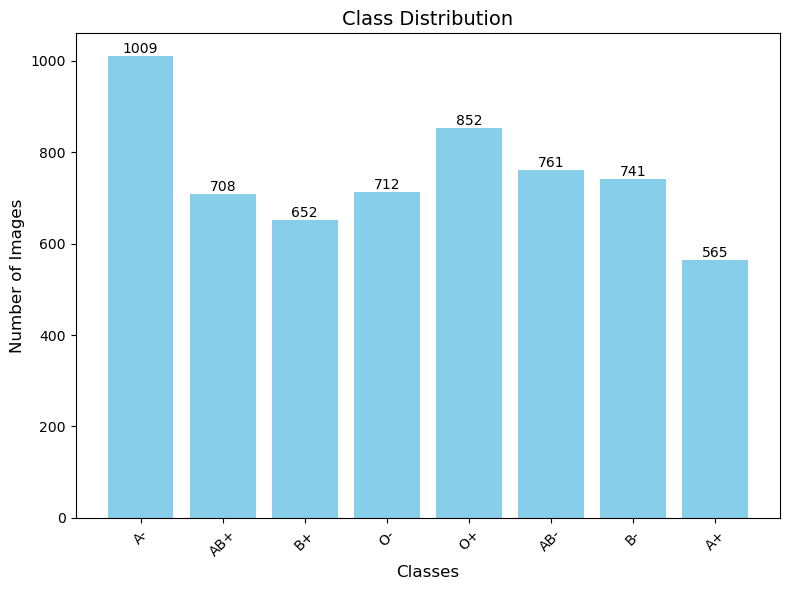

In [30]:
plot_class_distribution(class_names, class_counts)

In [31]:
max_count=max(class_counts.values())

In [32]:
# Oversampling means Data Augmentation
# Function to oversample a class
def oversample_class(class_id, count, max_count):
    
    # Ensure the dataset is unbatched for filtering
    unbatched_dataset=dataset.unbatch()
    
    #filter the dataset for the specific class
    class_dataset=unbatched_dataset.filter(lambda img, lbl:tf.equal(lbl, class_id))
    
    #calculate the number of repetitions needed 
    repeat_factor= max_count // count + (max_count % count>0)
    
    # Repeat the dataset to match the desiredd count
    return class_dataset.repeat(repeat_factor).take(max_count)

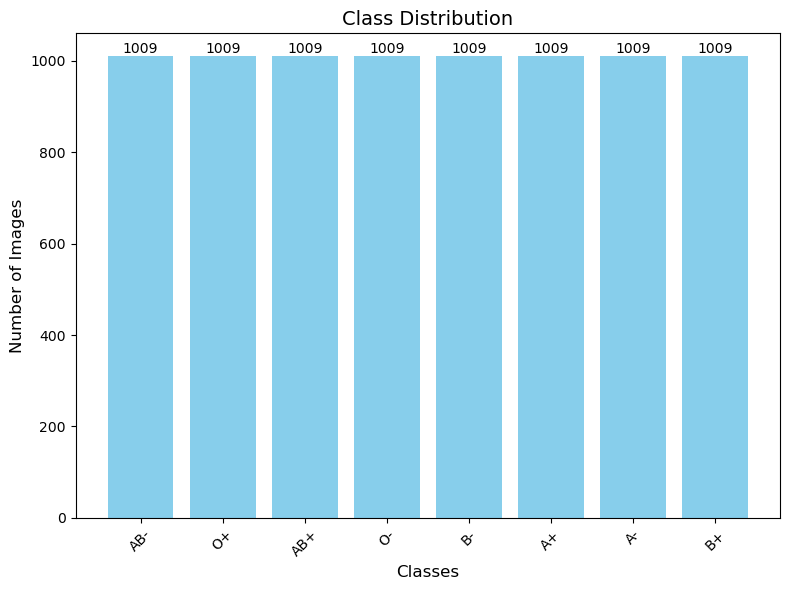

In [33]:
# Step1: Balance the dataset
balanced_datasets=[]
for class_id, count in class_counts.items():
    balanced_datasets.append(oversample_class(class_id, count, max_count))

#Step2:Combine balanced datasets
balanced_dataset=tf.data.Dataset.sample_from_datasets(balanced_datasets)

#Step3:Check balanced class distribution
balanced_class_counts=Counter([int(lbl.numpy()) for _, lbl in balanced_dataset])
plot_class_distribution(class_names, balanced_class_counts)

#Step4: Batch the balanced dataset
balanced_dataset= balanced_dataset.batch(BATCH_SIZE, drop_remainder=True)

In [34]:
for sample in balanced_dataset.take(10):
    print(sample[0].shape)

(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)


In [35]:
balanced_dataset_unbatched = balanced_dataset.unbatch()
dataset_size = sum(1 for _ in balanced_dataset_unbatched)
print(f"Total dataset size: {dataset_size}")

Total dataset size: 8064


In [36]:
# Unbatch the dataset to work at the sample level
balanced_dataset_unbatched= balanced_dataset.unbatch()

#compute the sizes based on dataset size and desired splits
#The sum of train_ratio and val_ratio should always be less than or equal to 1.
train_ratio=0.7    # 70% for training
val_ratio=0.2      # 20% for validation

train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)

# Split the dataset into training, validation, and test
train_dataset = balanced_dataset_unbatched.take(train_size)
val_test_dataset = balanced_dataset_unbatched.skip(train_size)
val_dataset = val_test_dataset.take(val_size)
test_dataset = val_test_dataset.skip(val_size)

# Rebatch the datasets after splitting
train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)
val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)
test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=True)

#Check the number of batches in each dataset
train_batch_count= sum(1 for _ in train_dataset)
val_batch_count= sum(1 for _ in val_dataset)
test_batch_count= sum(1 for _ in test_dataset)

print(f"Training dataset size: {train_batch_count * BATCH_SIZE}")
print(f"Validation dataset size: {val_batch_count * BATCH_SIZE}")
print(f"Testing dataset size: {test_batch_count * BATCH_SIZE}")

Training dataset size: 5632
Validation dataset size: 1600
Testing dataset size: 800


In [ ]:
#Using drop_remainder=False ensures you don't lose any data while batching.

In [40]:
def create_high_accuracy_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64,64,3)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(len(class_names), activation='softmax')

    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

#create the model
high_acc_model = create_high_accuracy_model()

In [41]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

#Define ReduceLORnPlateau callback to reduce learning rate when validation loss plateaus
reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',         #Monitor validation loss
    factor=0.5,                 #Reduce the learning rate by afactor of 0.5
    patience=3,                 #Wait for 3 epochs without improvement before reducing LR
    verbose=1,                  #Print a message when the learning rate is reduced
    min_lr=1e-6                 #Minimum learning rate to avoid too small values
)

#Define EarlyStopping callback to stop training when validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',             # Monitor validation loss
    patience=5,                     # Stop after 5 epochs without improvement
    verbose=1,                      # Print a message when training is stopped
    restore_best_weights=True       # Restore the model weights from the best epoch
)

In [42]:
# Train the model

history_high_acc = high_acc_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,    # Adjust the number of epochs based on your preference
    callbacks=[reduce_lr, early_stop]

)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 153s 749ms/step - accuracy: 0.1405 - loss: 22.8469 - val_accuracy: 0.2053 - val_loss: 1.9639 - learning_rate: 0.0010
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 141s 793ms/step - accuracy: 0.3106 - loss: 1.7646 - val_accuracy: 0.3511 - val_loss: 1.7823 - learning_rate: 0.0010
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 142s 804ms/step - accuracy: 0.4967 - loss: 1.2946 - val_accuracy: 0.5760 - val_loss: 1.2511 - learning_rate: 0.0010
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 144s 816ms/step - accuracy: 0.6367 - loss: 0.9735 - val_accuracy: 0.6336 - val_loss: 1.0768 - learning_rate: 0.0010
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 200s 798ms/step - accuracy: 0.6969 - loss: 0.8238 - val_accuracy: 0.6955 - val_loss: 0.9483 - learning_rate: 0.0010
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 144s 805ms/step - accuracy: 0.7349 - loss: 0.7289 - val_accuracy: 0.7482 - val_loss: 0.8220 - learning_rate: 0.0010
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 141s 798ms/step - accur

In [43]:
# Evaluate the model on validation data
high_acc_eval = high_acc_model.evaluate(val_dataset)
print(f"High Accuracy Model - Loss: {high_acc_eval[0]}, Accuracy: {high_acc_eval[1]}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 190ms/step - accuracy: 0.9412 - loss: 0.2553
High Accuracy Model - Loss: 0.2671354413032532, Accuracy: 0.9227941036224365


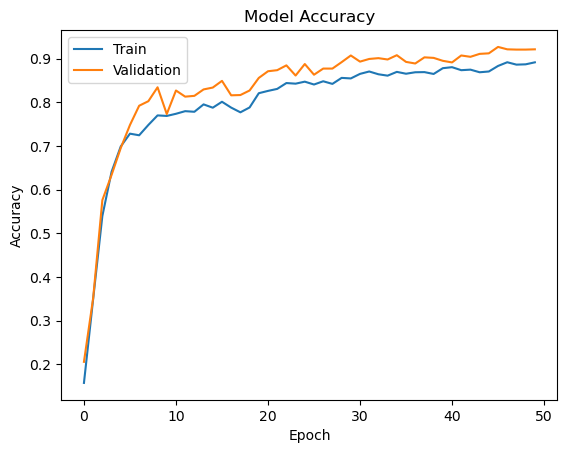

In [44]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_accuracy(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

#Call the function to display the accuracy graph
plot_accuracy(history_high_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Classification Report:
           

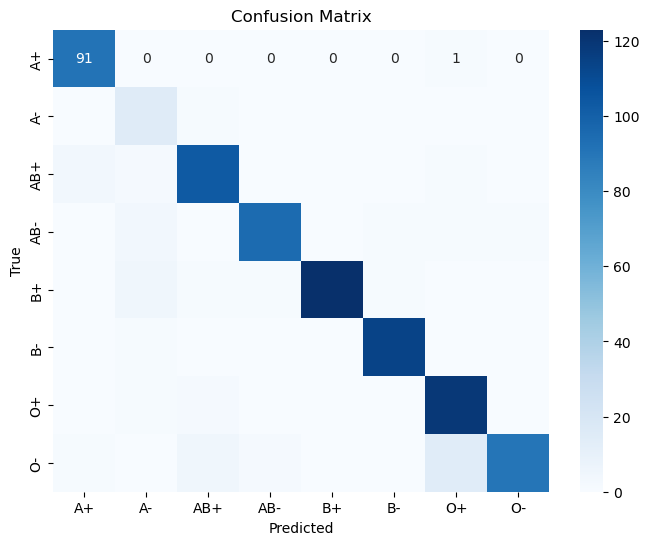

In [45]:
# Get predictions on the test dataset
y_true =[]     # True labels
y_pred =[]     # Predicted labels

# Iterate over the test dataset and collect the true and predicted labels
for images, labels in test_dataset:
    predictions = high_acc_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1) # Convert one-hot encoded predictions to class labels
    y_true.extend(labels.numpy())  # Convert tensor to numpy array and append
    y_pred.extend(predicted_labels) # Append the predicted labels

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:")
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [46]:
high_acc_model.save('model.h5')
print("Model Saved as HDFS format.")

Model Saved as HDFS format.
